In [77]:
import pandas as pd
DATASET_PATH = '../data/timeseries_daily-minimum-temperatures.csv'
ts_df = pd.read_csv(DATASET_PATH)

print(ts_df.shape)

(3650, 2)


In [78]:
print(ts_df.dtypes)
ts_df

Date                          str
Daily minimum temperatures    str
dtype: object


,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8
...,...,...
3645,12/27/1990,14
3646,12/28/1990,13.6
3647,12/29/1990,13.5
3648,12/30/1990,15.7


In [ ]:
ts_df['Date'] = pd.to_datetime(ts_df['Date'])

ValueError: time data "1/13/1981" doesn't match format "%d/%m/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
ts_df = ts_df.set_index('Date')
print(ts_df.dtypes)

Daily minimum temperatures    str
dtype: object


In [ ]:
ts_df['Year'] = ts_df.index.year
ts_df['Month'] = ts_df.index.month
ts_df['Day'] = ts_df.index.day
ts_df['Weekday Name'] = ts_df.index.day_name()
ts_df

,Daily minimum temperatures,Year,Month,Day,Weekday Name
Date,,,,,
1981-01-01,20.7,1981,1,1,Thursday
1981-01-02,17.9,1981,1,2,Friday
1981-01-03,18.8,1981,1,3,Saturday
1981-01-04,14.6,1981,1,4,Sunday
1981-01-05,15.8,1981,1,5,Monday
...,...,...,...,...,...
1990-12-27,14,1990,12,27,Thursday
1990-12-28,13.6,1990,12,28,Friday
1990-12-29,13.5,1990,12,29,Saturday


In [ ]:
ts_df['Daily minimum temperatures'] = pd.to_numeric(
    ts_df['Daily minimum temperatures'], errors = 'coerce'
)
ts_df.dtypes

Daily minimum temperatures    float64
Year                            int32
Month                           int32
Day                             int32
Weekday Name                      str
dtype: object

In [ ]:
ts_df.loc['1990-01-01' : '1991-01-01']

,Daily minimum temperatures,Year,Month,Day,Weekday Name
Date,,,,,
1990-01-01,14.8,1990,1,1,Monday
1990-01-02,13.3,1990,1,2,Tuesday
1990-01-03,15.6,1990,1,3,Wednesday
1990-01-04,14.5,1990,1,4,Thursday
1990-01-05,14.3,1990,1,5,Friday
...,...,...,...,...,...
1990-12-27,14.0,1990,12,27,Thursday
1990-12-28,13.6,1990,12,28,Friday
1990-12-29,13.5,1990,12,29,Saturday


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ts_df.loc['1990-01']

,Daily minimum temperatures,Year,Month,Day,Weekday Name
Date,,,,,
1990-01-01,14.8,1990,1,1,Monday
1990-01-02,13.3,1990,1,2,Tuesday
1990-01-03,15.6,1990,1,3,Wednesday
1990-01-04,14.5,1990,1,4,Thursday
1990-01-05,14.3,1990,1,5,Friday
1990-01-06,15.3,1990,1,6,Saturday
1990-01-07,16.4,1990,1,7,Sunday
1990-01-08,14.8,1990,1,8,Monday
1990-01-09,17.4,1990,1,9,Tuesday


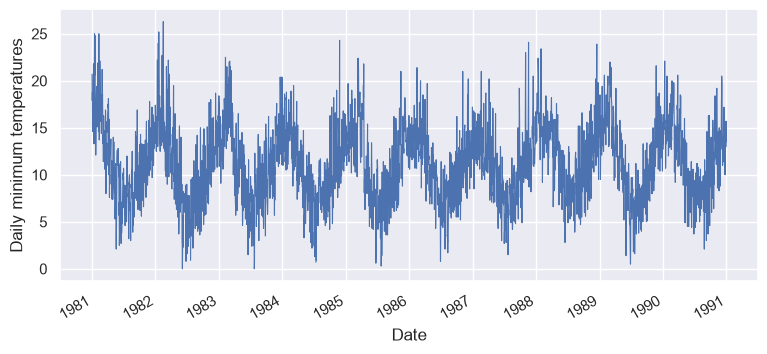

In [ ]:
sns.set(rc = {'figure.figsize': (9, 4)})
col_to_plot = 'Daily minimum temperatures'
ts_df[col_to_plot].plot(linewidth = 0.8)
plt.ylabel(col_to_plot)
plt.show()

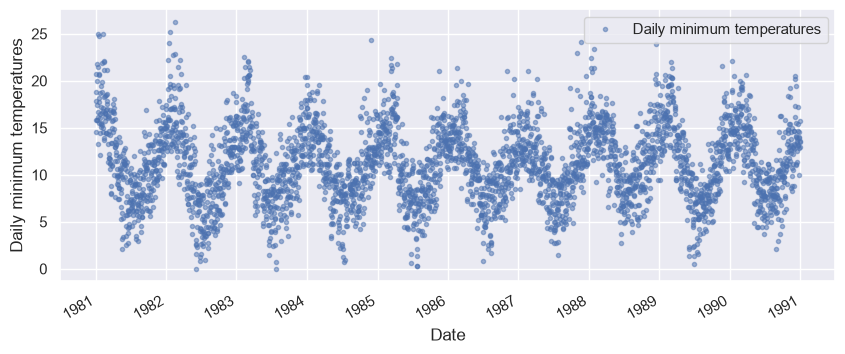

In [ ]:
cols_plot = ['Daily minimum temperatures']
ts_df[cols_plot].plot(
    marker = '.',
    alpha = 0.5,
    linestyle = 'None',
    figsize = (10, 4),
    subplots = True
)
plt.ylabel('Daily minimum temperatures')
plt.show()

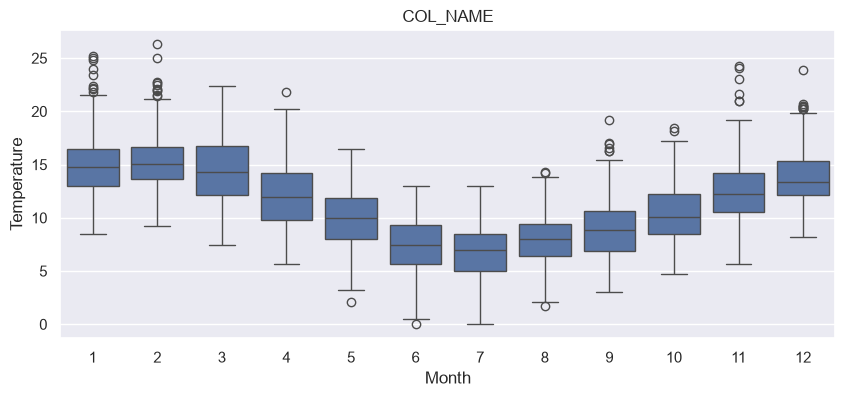

In [ ]:
COL_NAME = 'Daily minimum temperatures'
plt.figure(figsize=(10, 4))
sns.boxplot(data=ts_df, x = 'Month', y=COL_NAME)
plt.ylabel('Temperature')
plt.title('COL_NAME')
plt.show()

In [ ]:
#Frequencies
pd.date_range('1998-03-10', '1998-03-15', freq='D')

DatetimeIndex(['1998-03-10', '1998-03-11', '1998-03-12', '1998-03-13',
               '1998-03-14', '1998-03-15'],
              dtype='datetime64[us]', freq='D')

In [ ]:
#Resampling
data_columns = ['Daily minimum temperatures']
ts_weekly_mean = ts_df[data_columns].resample('W').mean()
ts_weekly_mean.head()

,Daily minimum temperatures
Date,
1981-01-04,18.000000
1981-01-11,17.542857
1981-01-18,20.371429
1981-01-25,15.771429
1981-02-01,16.657143


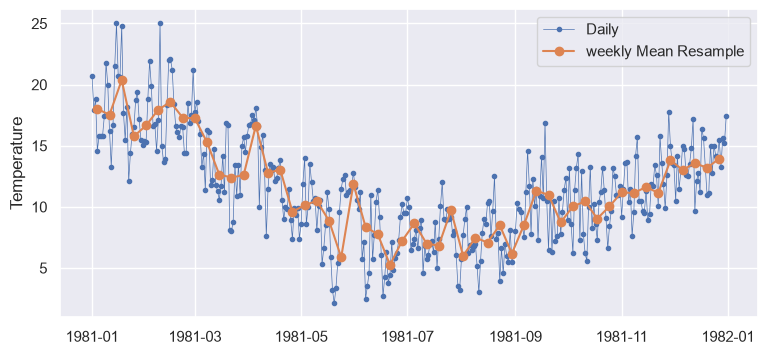

In [ ]:
start, end = '1981-01', '1981-12'
fig, ax = plt.subplots()
ax.plot(ts_df.loc[start:end, 'Daily minimum temperatures'],
marker = '.', linestyle = '-', linewidth=0.5, label = 'Daily')
ax.plot(ts_weekly_mean.loc[start:end, 'Daily minimum temperatures'], marker = 'o', linestyle='-', label = 'weekly Mean Resample')
ax.set_ylabel('Temperature')
ax.legend()
plt.show()

In [ ]:
ts_annual_df = ts_df[data_columns].resample('YE').sum(min_count=360)

ts_annual_df = ts_annual_df.set_index(ts_annual_df.index.year)

ts_annual_df.index.name = 'Year'

ts_annual_df



,Daily minimum temperatures
Year,
1981,4203.8
1982,3935.0
1983,4083.4
1984,3865.9
1985,4065.2
1986,3943.2
1987,3961.4
1988,4369.8
1989,4110.6


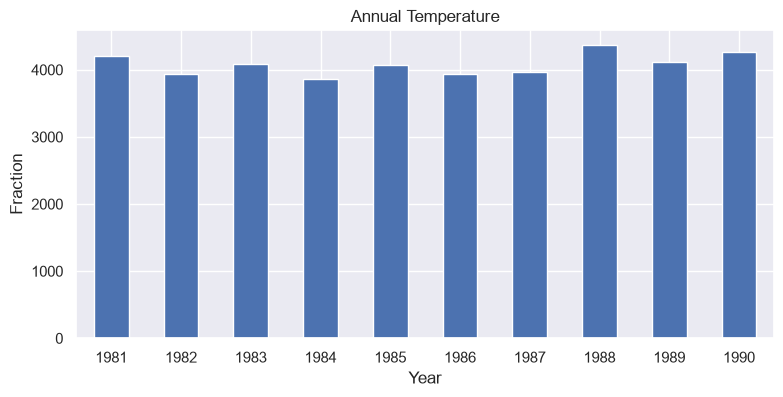

In [ ]:

ax = ts_annual_df.loc[1981:, 'Daily minimum temperatures'].plot.bar(color='C0')
ax.set_ylabel('Fraction')
ax.set_title('Annual Temperature')
plt.xticks(rotation = 0)
plt.show()

In [ ]:
data_fake = {
    'Name': ['A', 'B', 'C', 'D'],
    'Gender': ['X', 'Y', 'X', 'T']
}
data_fake = pd.DataFrame(data_fake)
data_fake.loc[2]

Name      C
Gender    X
Name: 2, dtype: str

AttributeError: Module 'sklearn' has no attribute '__version__ß'